Name: Vanchanagiri Alekhya
---

Enrollment Number: MML2025002
---


In [2]:
!pip install torch torchvision matplotlib numpy tqdm

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader


from torchvision import datasets, transforms
from torchvision.utils import make_grid


import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
z_dim = 100
batch_size = 128

epochs_gan = 31
epochs_wgan = 51

lr_gan = 0.0002
lr_wgan = 0.00005
beta1 = 0.5

n_critic = 5

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 475kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


In [4]:
def show_images(imgs, title="", nrow=8):
    imgs = imgs.detach().cpu()
    grid = make_grid(imgs, nrow=nrow, normalize=True)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.title(title)
    plt.show()

**Model-1: Standard GAN**
---

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1,1,28,28)

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        feat = self.features(x)
        return self.classifier(feat)

Epoch 1/31: 100%|██████████| 469/469 [00:15<00:00, 30.42it/s]


Epoch [1/31] | D Loss: 0.7831 | G Loss: 1.6757


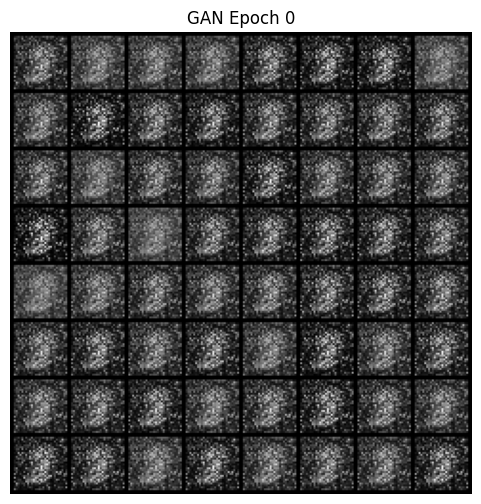

Epoch 2/31: 100%|██████████| 469/469 [00:14<00:00, 31.64it/s]


Epoch [2/31] | D Loss: 0.4558 | G Loss: 3.0655


Epoch 3/31: 100%|██████████| 469/469 [00:15<00:00, 30.60it/s]


Epoch [3/31] | D Loss: 0.3994 | G Loss: 3.6379


Epoch 4/31: 100%|██████████| 469/469 [00:15<00:00, 29.97it/s]


...

Epoch [9/31] | D Loss: 0.3882 | G Loss: 3.0223


Epoch 10/31: 100%|██████████| 469/469 [00:14<00:00, 32.14it/s]


Epoch [10/31] | D Loss: 0.3844 | G Loss: 3.0194


Epoch 11/31: 100%|██████████| 469/469 [00:14<00:00, 32.07it/s]

Epoch [11/31] | D Loss: 0.4709 | G Loss: 2.7534


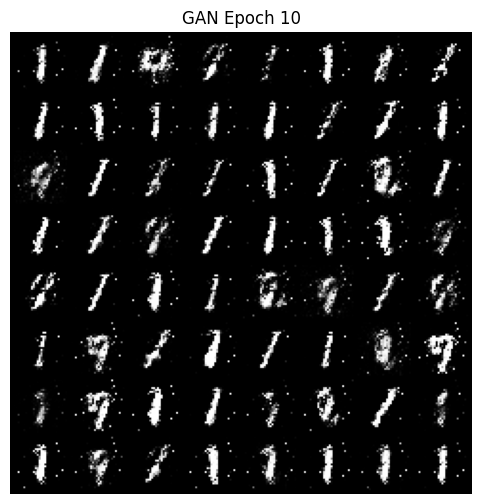

Epoch 12/31: 100%|██████████| 469/469 [00:14<00:00, 31.92it/s]


Epoch [12/31] | D Loss: 0.6119 | G Loss: 2.3333


Epoch 13/31: 100%|██████████| 469/469 [00:14<00:00, 32.02it/s]


Epoch [13/31] | D Loss: 0.6757 | G Loss: 2.1777


Epoch 14/31: 100%|██████████| 469/469 [00:15<00:00, 30.81it/s]


...

Epoch [19/31] | D Loss: 0.8123 | G Loss: 1.6855


Epoch 20/31: 100%|██████████| 469/469 [00:14<00:00, 31.90it/s]


Epoch [20/31] | D Loss: 0.8387 | G Loss: 1.6402


Epoch 21/31: 100%|██████████| 469/469 [00:14<00:00, 31.76it/s]

Epoch [21/31] | D Loss: 0.8549 | G Loss: 1.5968


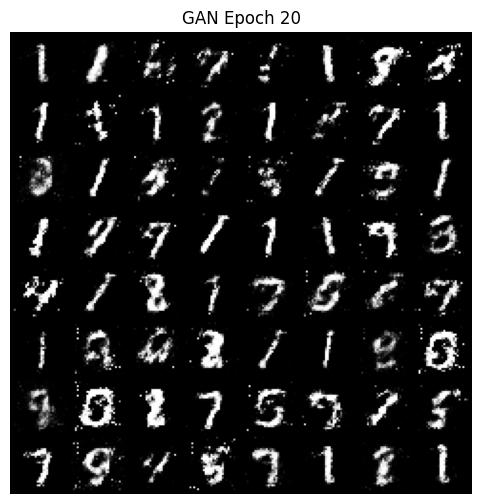

Epoch 22/31: 100%|██████████| 469/469 [00:14<00:00, 31.89it/s]


Epoch [22/31] | D Loss: 0.8736 | G Loss: 1.5389


Epoch 23/31: 100%|██████████| 469/469 [00:14<00:00, 31.82it/s]


Epoch [23/31] | D Loss: 0.8910 | G Loss: 1.5225


Epoch 24/31: 100%|██████████| 469/469 [00:15<00:00, 30.17it/s]


...

Epoch [29/31] | D Loss: 0.9365 | G Loss: 1.4348


Epoch 30/31: 100%|██████████| 469/469 [00:14<00:00, 31.80it/s]


Epoch [30/31] | D Loss: 0.9436 | G Loss: 1.4328


Epoch 31/31: 100%|██████████| 469/469 [00:14<00:00, 31.65it/s]


Epoch [31/31] | D Loss: 0.9494 | G Loss: 1.4083


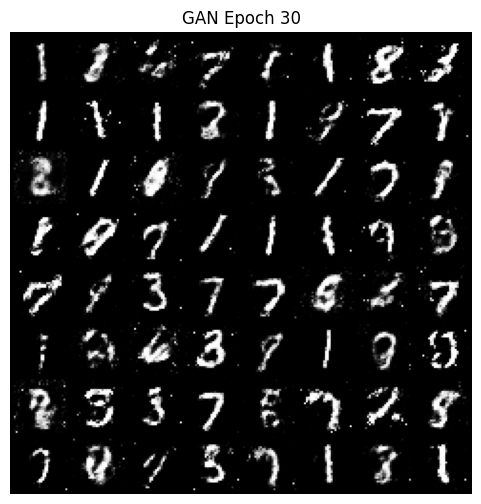

In [7]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr_gan, betas=(beta1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr_gan, betas=(beta1, 0.999))

gan_g_loss, gan_d_loss = [], []
fixed_z = torch.randn(64, z_dim).to(device)

for epoch in range(epochs_gan):

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for real, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs_gan}"):
        real = real.to(device)
        b = real.size(0)

        real_lbl = torch.ones(b, 1).to(device)
        fake_lbl = torch.zeros(b, 1).to(device)

        z = torch.randn(b, z_dim).to(device)
        fake = G(z)

        d_loss = criterion(D(real), real_lbl) + \
                 criterion(D(fake.detach()), fake_lbl)

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        g_loss = criterion(D(fake), real_lbl)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    avg_d_loss = epoch_d_loss / len(train_loader)
    avg_g_loss = epoch_g_loss / len(train_loader)

    gan_d_loss.append(avg_d_loss)
    gan_g_loss.append(avg_g_loss)

    print(
        f"Epoch [{epoch+1}/{epochs_gan}] | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f}"
    )

    if epoch % 10 == 0:
        show_images(G(fixed_z), f"GAN Epoch {epoch}")

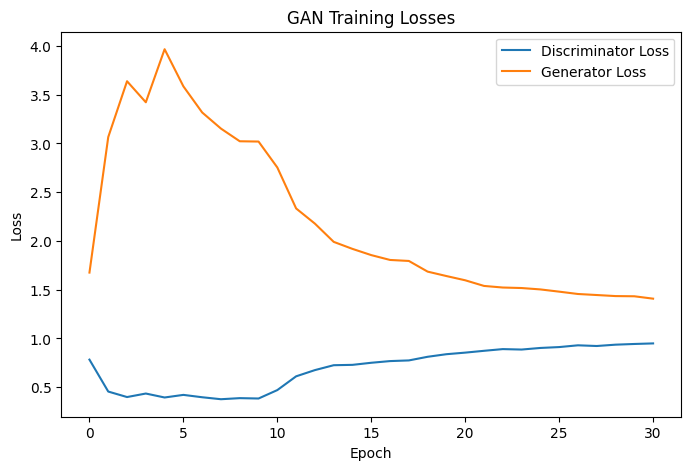

In [8]:
plt.figure(figsize=(8,5))
plt.plot(gan_d_loss, label="Discriminator Loss")
plt.plot(gan_g_loss, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.show()

**Model-2: VAE-GAN**
---

In [9]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784,512)
        self.mu = nn.Linear(512,z_dim)
        self.logvar = nn.Linear(512,z_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = torch.relu(self.fc(x))
        return self.mu(h), self.logvar(h)

In [10]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

Epoch 1/31: 100%|██████████| 469/469 [00:16<00:00, 29.20it/s]


[Epoch 1/31] D Loss: 1.4197 | G+E Loss: 1.9113


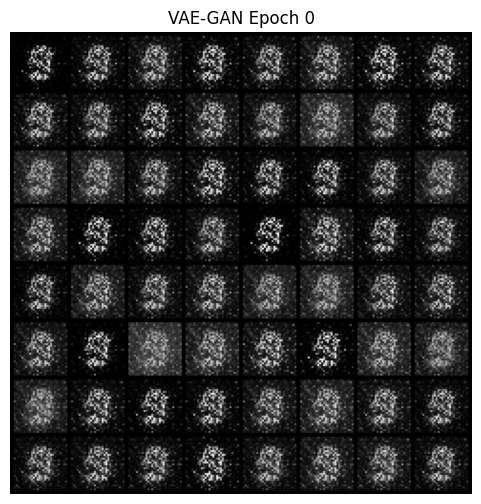

Epoch 2/31: 100%|██████████| 469/469 [00:16<00:00, 28.04it/s]


[Epoch 2/31] D Loss: 1.5811 | G+E Loss: 1.6774


Epoch 3/31: 100%|██████████| 469/469 [00:16<00:00, 28.15it/s]


[Epoch 3/31] D Loss: 1.4062 | G+E Loss: 1.8074


Epoch 4/31: 100%|██████████| 469/469 [00:16<00:00, 29.10it/s]


...

[Epoch 9/31] D Loss: 0.4040 | G+E Loss: 6.1529


Epoch 10/31: 100%|██████████| 469/469 [00:16<00:00, 28.88it/s]


[Epoch 10/31] D Loss: 0.4509 | G+E Loss: 5.2206


Epoch 11/31: 100%|██████████| 469/469 [00:16<00:00, 27.74it/s]


[Epoch 11/31] D Loss: 0.3629 | G+E Loss: 7.0551


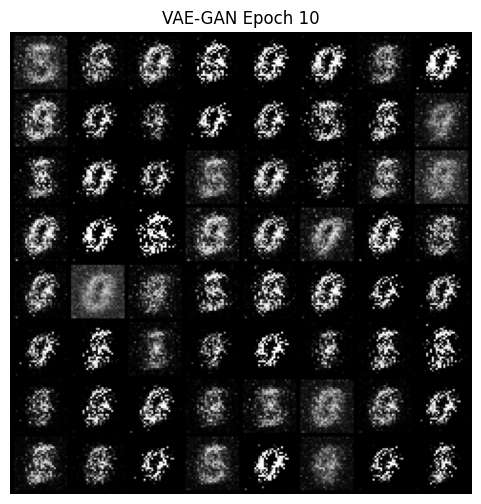

Epoch 12/31: 100%|██████████| 469/469 [00:18<00:00, 25.91it/s]


[Epoch 12/31] D Loss: 0.3636 | G+E Loss: 6.6976


Epoch 13/31: 100%|██████████| 469/469 [00:18<00:00, 24.95it/s]


[Epoch 13/31] D Loss: 0.3931 | G+E Loss: 5.8306


Epoch 14/31: 100%|██████████| 469/469 [00:16<00:00, 27.62it/s]


...

[Epoch 19/31] D Loss: 0.2606 | G+E Loss: 7.0095


Epoch 20/31: 100%|██████████| 469/469 [00:16<00:00, 28.67it/s]


[Epoch 20/31] D Loss: 0.3554 | G+E Loss: 6.8348


Epoch 21/31: 100%|██████████| 469/469 [00:16<00:00, 28.61it/s]


[Epoch 21/31] D Loss: 0.3559 | G+E Loss: 6.3297


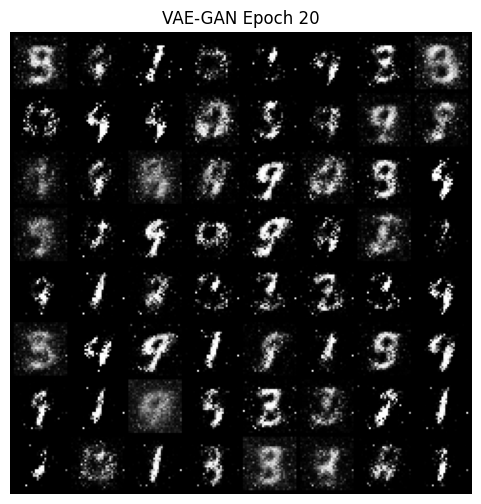

Epoch 22/31: 100%|██████████| 469/469 [00:17<00:00, 27.10it/s]


[Epoch 22/31] D Loss: 0.2729 | G+E Loss: 7.8900


Epoch 23/31: 100%|██████████| 469/469 [00:16<00:00, 28.24it/s]


[Epoch 23/31] D Loss: 0.2712 | G+E Loss: 7.3490


Epoch 24/31: 100%|██████████| 469/469 [00:17<00:00, 27.52it/s]


...

[Epoch 29/31] D Loss: 0.5400 | G+E Loss: 4.8913


Epoch 30/31: 100%|██████████| 469/469 [00:17<00:00, 26.80it/s]


[Epoch 30/31] D Loss: 0.5710 | G+E Loss: 4.5859


Epoch 31/31: 100%|██████████| 469/469 [00:16<00:00, 28.07it/s]


[Epoch 31/31] D Loss: 0.6196 | G+E Loss: 4.4030


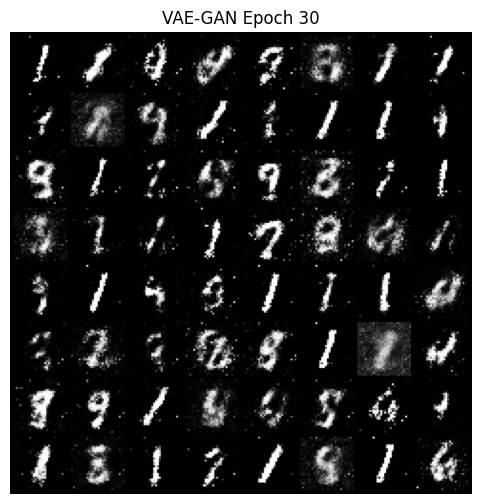

In [11]:
E = Encoder().to(device)
G = Generator().to(device)
D = Discriminator().to(device)

opt_E = optim.Adam(E.parameters(), lr=lr_gan)
opt_G = optim.Adam(G.parameters(), lr=lr_gan)
opt_D = optim.Adam(D.parameters(), lr=lr_gan)

criterion = nn.BCELoss()
mse = nn.MSELoss()

vae_g_loss, vae_d_loss = [], []

for epoch in range(epochs_gan):

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for real, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs_gan}"):
        real = real.to(device)
        b = real.size(0)

        real_lbl = torch.ones(b, 1).to(device)
        fake_lbl = torch.zeros(b, 1).to(device)

        mu, logvar = E(real)
        z = reparameterize(mu, logvar)
        recon = G(z)

        z_prior = torch.randn(b, z_dim).to(device)
        fake = G(z_prior)

        d_loss = (
            criterion(D(real), real_lbl) +
            criterion(D(recon.detach()), fake_lbl) +
            criterion(D(fake.detach()), fake_lbl)
        )

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        for p in D.parameters():
            p.requires_grad = False

        mu, logvar = E(real)
        z = reparameterize(mu, logvar)
        recon = G(z)

        kl_loss = -0.5 * torch.mean(1 + logvar - mu**2 - logvar.exp())

        f_real = D.features(real.view(b, -1))
        f_recon = D.features(recon.view(b, -1))
        recon_loss = mse(f_real, f_recon)

        adv_loss = criterion(D(recon), real_lbl)

        g_loss = recon_loss + adv_loss + kl_loss

        opt_E.zero_grad()
        opt_G.zero_grad()
        g_loss.backward()
        opt_E.step()
        opt_G.step()

        for p in D.parameters():
            p.requires_grad = True

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    avg_d = epoch_d_loss / len(train_loader)
    avg_g = epoch_g_loss / len(train_loader)

    vae_d_loss.append(avg_d)
    vae_g_loss.append(avg_g)
    print(
        f"[Epoch {epoch+1}/{epochs_gan}] "
        f"D Loss: {avg_d:.4f} | "
        f"G+E Loss: {avg_g:.4f}"
    )

    if epoch % 10 == 0:
        show_images(
            G(torch.randn(64, z_dim).to(device)),
            f"VAE-GAN Epoch {epoch}"
        )

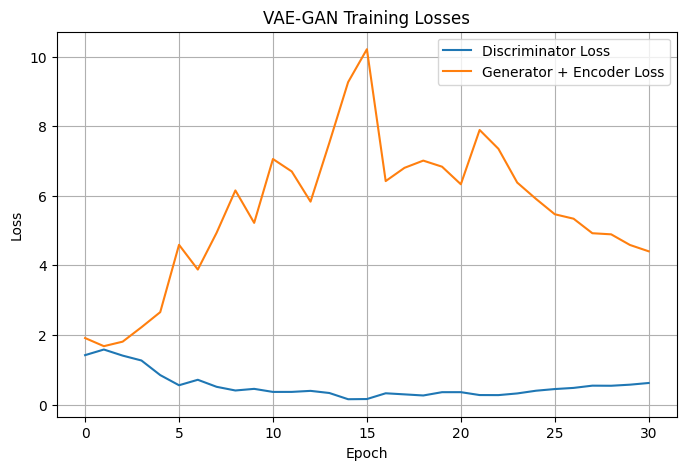

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(vae_d_loss, label="Discriminator Loss")
plt.plot(vae_g_loss, label="Generator + Encoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE-GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

**Model-3: VAE-WGAN**
---

In [13]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(784,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2)
        )
        self.out = nn.Linear(256,1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.out(self.features(x))

Epoch 1/51: 100%|██████████| 469/469 [00:23<00:00, 19.79it/s]


[Epoch 1/51] C: -0.6073 | G: 1.1737 | W: 0.6356 | KL: 0.1178


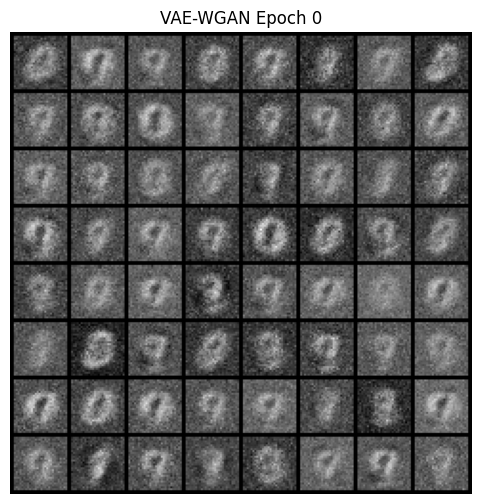

Epoch 2/51: 100%|██████████| 469/469 [00:24<00:00, 19.43it/s]


[Epoch 2/51] C: -0.6158 | G: 1.0027 | W: 0.3695 | KL: 0.0912


Epoch 3/51: 100%|██████████| 469/469 [00:23<00:00, 19.60it/s]


[Epoch 3/51] C: -0.5396 | G: 1.0741 | W: 0.6922 | KL: 0.1140


Epoch 4/51: 100%|██████████| 469/469 [00:24<00:00, 19.38it/s]


...

[Epoch 19/51] C: -0.3317 | G: 0.8204 | W: 0.7745 | KL: 0.1269


Epoch 20/51: 100%|██████████| 469/469 [00:23<00:00, 19.70it/s]


[Epoch 20/51] C: -0.3283 | G: 0.8385 | W: 0.0925 | KL: 0.1276


Epoch 21/51: 100%|██████████| 469/469 [00:23<00:00, 19.85it/s]


[Epoch 21/51] C: -0.3184 | G: 0.8321 | W: 0.2137 | KL: 0.1343


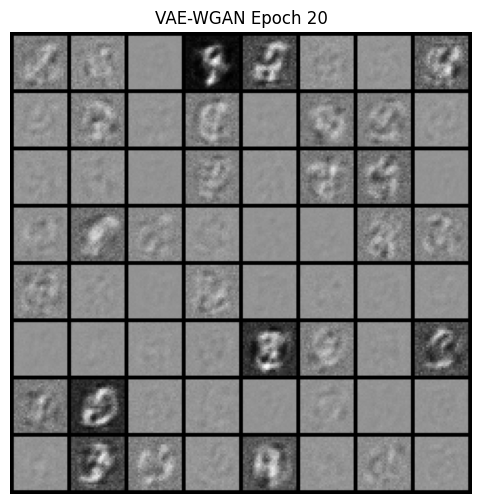

Epoch 22/51: 100%|██████████| 469/469 [00:23<00:00, 19.59it/s]


[Epoch 22/51] C: -0.3112 | G: 0.8404 | W: 0.2765 | KL: 0.1371


Epoch 23/51: 100%|██████████| 469/469 [00:23<00:00, 19.59it/s]


[Epoch 23/51] C: -0.3050 | G: 0.8326 | W: 0.4346 | KL: 0.1405


Epoch 24/51: 100%|██████████| 469/469 [00:23<00:00, 19.96it/s]


...

[Epoch 39/51] C: -0.2385 | G: 0.8127 | W: 0.3797 | KL: 0.1418


Epoch 40/51: 100%|██████████| 469/469 [00:23<00:00, 19.85it/s]


[Epoch 40/51] C: -0.2335 | G: 0.8198 | W: 0.5710 | KL: 0.1490


Epoch 41/51: 100%|██████████| 469/469 [00:23<00:00, 19.93it/s]


[Epoch 41/51] C: -0.2318 | G: 0.8239 | W: 0.0797 | KL: 0.1423


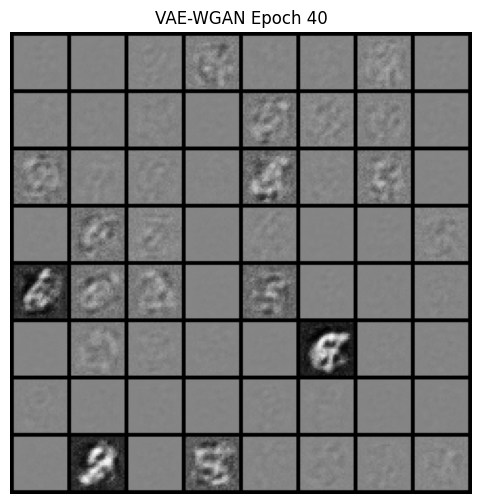

Epoch 42/51: 100%|██████████| 469/469 [00:24<00:00, 19.40it/s]


[Epoch 42/51] C: -0.2291 | G: 0.8247 | W: 0.1282 | KL: 0.1404


Epoch 43/51: 100%|██████████| 469/469 [00:23<00:00, 19.66it/s]


[Epoch 43/51] C: -0.2270 | G: 0.8237 | W: 0.8076 | KL: 0.1476


Epoch 44/51: 100%|██████████| 469/469 [00:23<00:00, 19.58it/s]


...

[Epoch 49/51] C: -0.2131 | G: 0.8119 | W: 0.4342 | KL: 0.1493


Epoch 50/51: 100%|██████████| 469/469 [00:24<00:00, 19.27it/s]


[Epoch 50/51] C: -0.2111 | G: 0.7970 | W: 0.0211 | KL: 0.1474


Epoch 51/51: 100%|██████████| 469/469 [00:24<00:00, 19.31it/s]

[Epoch 51/51] C: -0.2100 | G: 0.7946 | W: 0.7626 | KL: 0.1455


In [14]:
C = Critic().to(device)
G = Generator().to(device)
E = Encoder().to(device)

lr_wgan = 5e-5
n_critic = 5
clip_value = 0.01
beta = 1.0

opt_C = optim.RMSprop(C.parameters(), lr=lr_wgan)
opt_G = optim.RMSprop(G.parameters(), lr=lr_wgan)
opt_E = optim.RMSprop(E.parameters(), lr=lr_wgan)

wgan_g_loss, wgan_c_loss = [], []

for epoch in range(epochs_wgan):

    epoch_c_loss = 0.0
    epoch_g_loss = 0.0

    for real, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs_wgan}"):

        real = real.to(device)
        b = real.size(0)

        for _ in range(n_critic):

            mu, logvar = E(real)
            z_recon = reparameterize(mu, logvar)
            recon = G(z_recon)

            z_fake = torch.randn(b, z_dim).to(device)
            fake = G(z_fake)

            C_real = C(real)
            C_fake = C(fake.detach())
            C_recon = C(recon.detach())

            c_loss = (
                -C_real.mean()
                + C_fake.mean()
                + C_recon.mean()
            )

            opt_C.zero_grad()
            c_loss.backward()
            opt_C.step()

            for p in C.parameters():
                p.data.clamp_(-clip_value, clip_value)

        mu, logvar = E(real)
        z_recon = reparameterize(mu, logvar)
        recon = G(z_recon)

        z_fake = torch.randn(b, z_dim).to(device)
        fake = G(z_fake)

        KL_loss = -0.5 * torch.mean(
            1 + logvar - mu.pow(2) - logvar.exp()
        )

        with torch.no_grad():
            feat_real = C.features(real.view(b, -1))
        feat_recon = C.features(recon.view(b, -1))
        feat_loss = torch.mean((feat_real - feat_recon) ** 2)

        pixel_loss = torch.mean((real - recon) ** 2)

        g_w_loss = -C(fake).mean() - C(recon).mean()

        g_loss = (
            g_w_loss
            + feat_loss
            + pixel_loss
            + beta * KL_loss
        )

        opt_G.zero_grad()
        opt_E.zero_grad()
        g_loss.backward()
        opt_G.step()
        opt_E.step()

        epoch_c_loss += c_loss.item()
        epoch_g_loss += g_loss.item()

    avg_c = epoch_c_loss / len(train_loader)
    avg_g = epoch_g_loss / len(train_loader)

    wgan_c_loss.append(avg_c)
    wgan_g_loss.append(avg_g)

    print(
        f"[Epoch {epoch+1}/{epochs_wgan}] "
        f"C: {avg_c:.4f} | "
        f"G: {avg_g:.4f} | "
        f"W: {g_w_loss.item():.4f} | "
        f"KL: {KL_loss.item():.4f}"
    )

    if epoch % 20 == 0:
        show_images(
            G(torch.randn(64, z_dim).to(device)),
            f"VAE-WGAN Epoch {epoch}"
        )

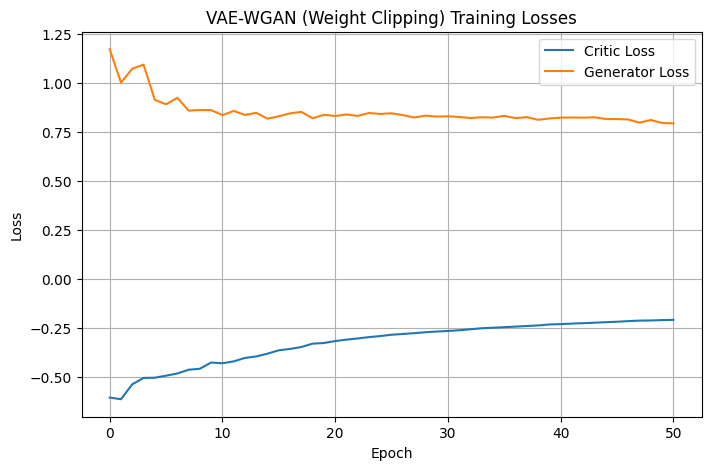

In [15]:
plt.figure(figsize=(8,5))
plt.plot(wgan_c_loss, label="Critic Loss")
plt.plot(wgan_g_loss, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE-WGAN (Weight Clipping) Training Losses")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
torch.save({
    'encoder_state_dict': E.state_dict(),
    'generator_state_dict': G.state_dict(),
    'critic_state_dict': C.state_dict(),
    'optimizer_E_state_dict': opt_E.state_dict(),
    'optimizer_G_state_dict': opt_G.state_dict(),
    'optimizer_C_state_dict': opt_C.state_dict(),
    'epoch': epoch,
}, 'vae_wgan_weight_clipping_best.pth')

print("Best VAE-WGAN (weight clipping) model saved!")

Best VAE-WGAN (weight clipping) model saved!


In [17]:
checkpoint = torch.load('vae_wgan_weight_clipping_best.pth', map_location=device)

E.load_state_dict(checkpoint['encoder_state_dict'])
G.load_state_dict(checkpoint['generator_state_dict'])
C.load_state_dict(checkpoint['critic_state_dict'])

opt_E.load_state_dict(checkpoint['optimizer_E_state_dict'])
opt_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
opt_C.load_state_dict(checkpoint['optimizer_C_state_dict'])

start_epoch = checkpoint['epoch']
print(f"Loaded VAE-WGAN (weight clipping) model from epoch {start_epoch}")

Loaded VAE-WGAN (weight clipping) model from epoch 50


In [34]:
from google.colab import files

files.download('vae_wgan_weight_clipping_best.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
def latent_interpolation(encoder, generator, img1, img2, steps=10):
    encoder.eval()
    generator.eval()

    with torch.no_grad():
        mu1,_ = encoder(img1)
        mu2,_ = encoder(img2)

        alphas = torch.linspace(0,1,steps).to(device)
        zs = [(1-a)*mu1 + a*mu2 for a in alphas]
        zs = torch.cat(zs, dim=0)

        samples = generator(zs).view(-1,1,28,28)
        show_images(samples, "Latent Interpolation (VAE-WGAN)", nrow=steps)

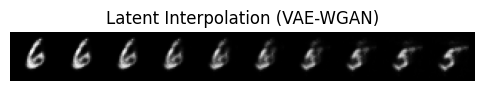

In [33]:

imgs,_ = next(iter(train_loader))
img1 = imgs[0:1].to(device)
img2 = imgs[1:2].to(device)

latent_interpolation(E, G, img1, img2)